In [ ]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum, avg, max, min, count,
    when, isnan,
    hour, unix_timestamp, round, dayofweek
)
import matplotlib.pyplot as plt

In [ ]:
spark= SparkSession.builder \
.appName("Task1") \
.getOrCreate()

In [ ]:
# for Big data analysis, we need a large dataset. A dataset with large amount of values in this notebook is the NYC taxi dataset from the official NYC taxi website.
# Since the dataset form the official website was in .parquet extension, we can read the file in pyspark as follows:
from google.colab import drive
drive.mount('/content/drive')
df=spark.read.parquet('yellow_tripdata_2025-01.parquet')


Mounted at /content/drive


In [ ]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [ ]:
df.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee']

In [ ]:
# For big data analysis, we will combine two files worth of NYC taxi data to obtain better insights
df_jan=df
df_feb=spark.read.parquet('/content/drive/MyDrive/Pyspark_training/yellow_tripdata_2025-02.parquet')
df_2025=df_jan.union(df_feb)
df_2025.count()

7052769

In [ ]:
# Now lets clean the data by checking null values
df_2025.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_2025.columns
]).show()
# As we can see we have some null values that need to be cleaned

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|        1347086|            0|   1347086|           1347086|           0|    

In [ ]:
# We will begin by by dropping the columns that are not useful
df_2025=df_2025.drop('store_and_fwd_flag','RatecodeID')
df_2025.show(5)

+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|              1|          1.6|         229|         237|           1|       10.0|  3.5|    0.5|       3.0|         0.0|                  1.0|        18.0|             

In [ ]:
# Now that unecessary columns are dropped, we will now go to passenger count and handle the missing values
df_2025=df_2025.fillna({"passenger_count": 1}) # As minimum 1 passenger needs to be there for a ride. we replace the null values with 1
df_2025.show(5)

+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|              1|          1.6|         229|         237|           1|       10.0|  3.5|    0.5|       3.0|         0.0|                  1.0|        18.0|             

In [ ]:
df_2025.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_2025.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|              0|            0|           0|           0|           0|          0|    0|      0|         0|           0|                    0|           0|             

In [ ]:
# We will handle the congestion surcharge values by replacing the null values witb 0. The reason is that congestion surcharge is not applied to every tip. Meaning it only applied to specific zones and at certain times
# So if the value is missing, it is most likely that no congestion surcharge was applied
df_2025=df_2025.fillna({"congestion_surcharge": 0})

 # Now we will fill the null values of Airport_fees by repplacing the null values with 0. The only logical reason is that if there is no airport ride there must be no airport fees as well
df_2025=df_2025.fillna({"airport_fee": 0})





In [ ]:
# Now that we have handled the missing values, we will check for any missing values again to confirm the data is cleaned
df_2025.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_2025.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|              0|            0|           0|           0|           0|          0|    0|      0|         0|           0|                    0|           0|             

In [ ]:
# Now we will check for any duplicates
before=df_2025.count()
after=df_2025.dropDuplicates().count()
print("Duplicate values :",before - after)

Duplicate values : 0


In [22]:
df_2025.groupBy("tpep_pickup_datetime", "PULocationID", "DOLocationID") \
  .count() \
  .filter("count > 1") \
  .show()
  #Potential duplicate patterns were observed based on pickup time and location; however, since no unique trip identifier was available, these records were retained to avoid accidental data loss.

+--------------------+------------+------------+-----+
|tpep_pickup_datetime|PULocationID|DOLocationID|count|
+--------------------+------------+------------+-----+
| 2025-01-01 00:01:41|          79|         107|    2|
| 2025-01-01 00:30:29|         132|         265|    2|
| 2025-01-01 01:23:42|         143|         186|    2|
| 2025-01-01 01:28:31|         145|         161|    2|
| 2025-01-01 02:39:47|         249|         114|    2|
| 2025-01-01 02:07:05|         100|         244|    2|
| 2025-01-01 03:48:19|         143|         236|    2|
| 2025-01-01 05:54:41|         162|         100|    2|
| 2025-01-01 07:29:48|          75|         263|    2|
| 2025-01-01 08:33:29|         132|         243|    2|
| 2025-01-01 14:52:54|         237|         161|    2|
| 2025-01-01 15:31:29|         230|         230|    2|
| 2025-01-01 15:49:02|         170|         164|    2|
| 2025-01-01 03:45:40|         114|         114|    2|
| 2025-01-02 06:11:55|         132|         219|    2|
| 2025-01-

In [21]:
df_2025=df_2025.withColumn("trip_duration_mins",
                           round((unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime")))/60,2
                           )
)

df_2025 = df_2025.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df_2025.show()

+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+------------------+-----------+-----------+---------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|trip_duration_mins|pickup_hour|day_of_week| day_name|
+--------+--------------------+---------------------+---------------+-------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+------------------+-----------+-----------+---------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|        

In [23]:
# Now we will find out the peak demand hours
df_2025.groupBy("pickup_hour") \
.count() \
.orderBy("pickup_hour",ascending=False) \
.show(50)
# Peak demand is observed during the evening hours. Highest number of trips were recorded during the hour 18:00, followed by the hour 17:00. This indicates strong commuting pattern often due to traffic returning from office.


+-----------+------+
|pickup_hour| count|
+-----------+------+
|         23|295041|
|         22|389463|
|         21|426586|
|         20|410648|
|         19|458341|
|         18|542354|
|         17|501835|
|         16|430258|
|         15|420238|
|         14|396182|
|         13|367570|
|         12|348555|
|         11|317148|
|         10|296563|
|          9|288094|
|          8|281662|
|          7|203463|
|          6|101323|
|          5| 46916|
|          4| 42996|
|          3| 59722|
|          2| 91807|
|          1|135019|
|          0|200985|
+-----------+------+



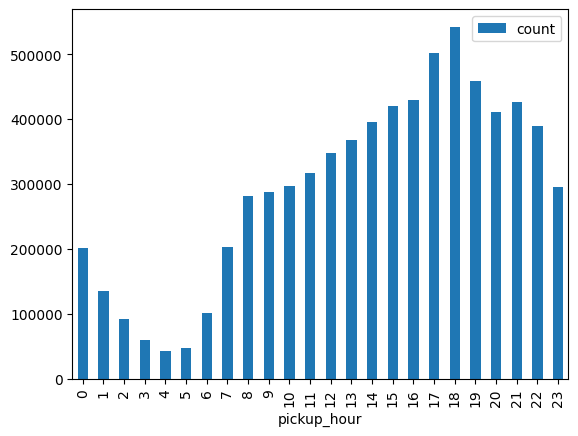

In [24]:
# Lets visualize the pickup hours data

pdf=df_2025.groupBy("pickup_hour") \
.count() \
.orderBy("pickup_hour") \
.toPandas()

pdf.plot(x="pickup_hour",y="count",kind="bar")
plt.show()

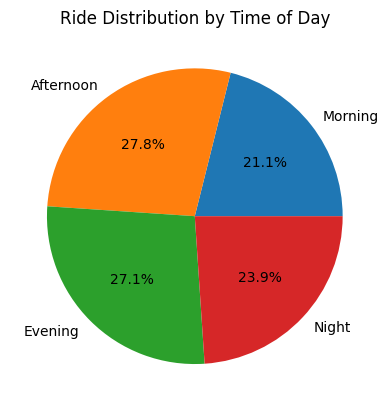

In [18]:
# Lets make a clear comparision between between the demand during morning,afternoon and evening.
pdf = df_2025.withColumn(
    "time_period",
    when((col("pickup_hour") >= 6) & (col("pickup_hour") < 12), "Morning")
    .when((col("pickup_hour") >= 12) & (col("pickup_hour") < 17), "Afternoon")
    .when((col("pickup_hour") >= 17) & (col("pickup_hour") < 21), "Evening")
    .otherwise("Night")
).groupBy("time_period").count().toPandas()

#Lets visualize the information using piechart
plt.figure()
order = ["Morning", "Afternoon", "Evening", "Night"]
pdf["time_period"] = pd.Categorical(pdf["time_period"], categories=order, ordered=True)
pdf = pdf.sort_values("time_period")
plt.pie(
    pdf["count"],
    labels=pdf["time_period"],
    autopct='%1.1f%%'
)
plt.title("Ride Distribution by Time of Day")
plt.show()
#The distribution of rides across different time periods shows that the highest demand occurs during the afternoon, followed closely by evening hours. This indicates that ride activity is not limited to traditional commute times.
# But it remains consistently high throughout the day. Night-time demand also remains significant, highlighting continuous urban mobility, while morning demand is comparatively lower.

+-----------+-------+
|day_of_week|  count|
+-----------+-------+
|          1| 872367|
|          2| 762739|
|          3| 932541|
|          4|1087317|
|          5|1169370|
|          6|1167002|
|          7|1061433|
+-----------+-------+



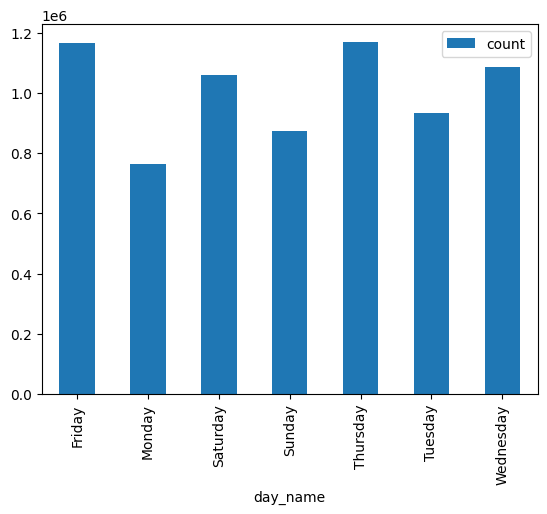

In [19]:
# Now let us see the trips by the day so we can identify the traffic during week days and weekends
df_2025 = df_2025.withColumn("day_of_week", dayofweek(col("tpep_pickup_datetime")))
df_2025.groupBy("day_of_week").count().orderBy("day_of_week").show()
df_2025 = df_2025.withColumn(
    "day_name",
    when(col("day_of_week") == 1, "Sunday")
    .when(col("day_of_week") == 2, "Monday")
    .when(col("day_of_week") == 3, "Tuesday")
    .when(col("day_of_week") == 4, "Wednesday")
    .when(col("day_of_week") == 5, "Thursday")
    .when(col("day_of_week") == 6, "Friday")
    .when(col("day_of_week") == 7, "Saturday")
)
# let is visualize the information obtained
pdf= df_2025.groupBy("day_name") \
    .count() \
    .orderBy("day_name") \
    .toPandas()

pdf.plot(x="day_name", y="count", kind="bar")
plt.show()

+------------+------+
|PULocationID| count|
+------------+------+
|         161|331388|
|         237|320996|
|         236|303740|
|         132|271600|
|         230|240357|
|         186|232520|
|         162|231651|
|         142|214944|
|         234|198533|
|         170|192907|
+------------+------+



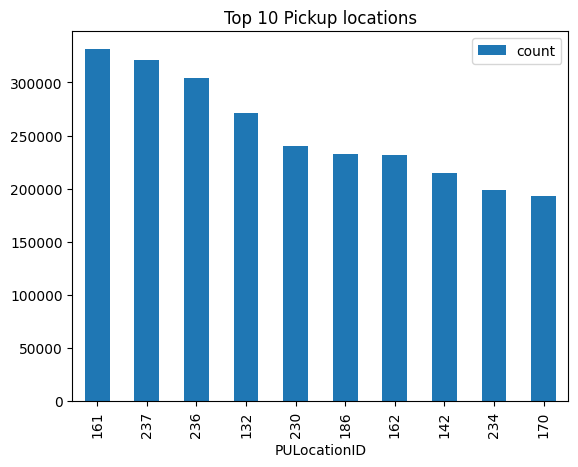

   PULocationID   count  percentage
0           161  331388    4.698694
1           237  320996    4.551347
2           236  303740    4.306677
3           132  271600    3.850970
4           230  240357    3.407981
5           186  232520    3.296861
6           162  231651    3.284540
7           142  214944    3.047654
8           234  198533    2.814965
9           170  192907    2.735195


In [29]:
# The top pickup locations represent high-demand zones where a significant number of taxi trips originate. These areas are likely major commercial, residential, or transit hubs, indicating concentrated urban mobility patterns.
toplocation=df_2025.groupBy("PULocationID") \
.count() \
.orderBy("count",ascending=False) \
.limit(10)
toplocation.show()
pdf= toplocation.toPandas()
pdf.plot(x="PULocationID",y="count",kind="bar")
plt.title("Top 10 Pickup locations")
plt.show()

#Let us the percentage of contribuiton of each pickup location
totaltrips=df_2025.count()
pdf["percentage"]=(pdf["count"]/totaltrips)*100
print(pdf)
# A small number of locations contribute disproportionately to total ride demand.

In [44]:
# For revenue analysis, only valid payment types (credit card and cash) were considered. .
df_valid = df_2025.filter(col("payment_type").isin([1, 2]))

df_valid.groupBy("payment_type") \
    .avg("total_amount") \
    .withColumnRenamed("avg(total_amount)", "avg_fare") \
    .orderBy("avg_fare", ascending=False) \
    .show()
df_valid.groupBy("payment_type") \
.agg(
    avg("total_amount").alias("avg_fare"),
    count("*").alias("Number_of_trips")
) \
.orderBy("avg_fare",ascending=False) \
.show()
# The analysis shows that credit card transactions dominate both in terms of number of trips and average fare.
# The results show that, significantly high usage and higher average trip value, digital payments( credit cards) is the preferred mode of payment for longer or high cost trips
# Meanwhile, cash payments are less frequent and associated with lower-value rides.

+------------+-----------------+
|payment_type|         avg_fare|
+------------+-----------------+
|           1|28.01570129324061|
|           2| 21.5920279349519|
+------------+-----------------+

+------------+-----------------+---------------+
|payment_type|         avg_fare|Number_of_trips|
+------------+-----------------+---------------+
|           1|28.01570129324061|        4780568|
|           2| 21.5920279349519|         729910|
+------------+-----------------+---------------+



# **Conclusion:**
This project demonstrates how PySpark can be used to efficiently process and analyze large-scale transportation data. Key insights include peak demand periods, high-traffic pickup zones, and differences in customer payment behavior. The use of distributed processing ensures scalability and performance when handling large datasets.

## **Insights obtained:**


*   Time-based analysis showed that ride demand peaks during the afternoon and evening hours, with the highest activity observed around 6 PM, indicating strong commuting patterns. Additionally, demand increases towards the end of the week, with Thursday and Friday recording the highest number of trips, suggesting increased mobility during pre-weekend periods.

*   Location-based analysis identified a small number of pickup zones contributing to a large share of total trips, indicating concentrated demand in specific high-traffic urban areas.



*   Revenue analysis highlighted that credit card transactions dominate both in terms of volume and average fare. Users opting for digital payments tend to take higher-value trips compared to cash users, reflecting differences in customer behavior and trip characteristics.


Overall, the project showcases how distributed data processing using PySpark enables efficient handling of large-scale datasets while uncovering meaningful insights related to urban transportation patterns.

These insights can be leveraged to optimize taxi operations, improve resource allocation, and enhance customer experience in urban transportation systems.




## **Reference:**

Dataset: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page




